In [13]:
#Bank Fraud Transaction Detection
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    {
        "transaction_amount": [447, 944.784, 849, 8584, 133, 7458, 1485, 16484.8, 4854, 45],
        "location": ["A", "B", "D", "C", "E", "F", "G", "H", "I", "J"],
        "time": [2, 12, 24, 13, 1, 5, 23, 6, 8, 24],
        "account_activity": [
            "active", "inactive", "active", "active", "inactive",
            "active", "active", "active", "active", "inactive"
        ]
    }
)
df

,transaction_amount,location,time,account_activity
0,447.000,A,2,active
1,944.784,B,12,inactive
2,849.000,D,24,active
3,8584.000,C,13,active
4,133.000,E,1,inactive
5,7458.000,F,5,active
6,1485.000,G,23,active
7,16484.800,H,6,active
8,4854.000,I,8,active
9,45.000,J,24,inactive



Unusual Transactions:
   transaction_amount location  time Account_Activity Unusual_Transaction  \
1           35656.980        B     3           active                 Yes   
4             650.435        E    10           active                 Yes   
7            5465.990        D     4           active                 Yes   

  Fraud_Pattern  
1         Fraud  
4         Fraud  
7         Fraud  
--------------------------------------------------------------------------------------

High Risk Accounts:
   transaction_amount location  time Account_Activity Unusual_Transaction  \
0             54656.0        A     1         inactive                  No   
3               455.0        D     6         inactive                  No   
5             65454.0        F     4         inactive                  No   
6            544414.0        G     3         inactive                  No   
9             24655.0        C     5         inactive                  No   

  Fraud_Pattern  
0      

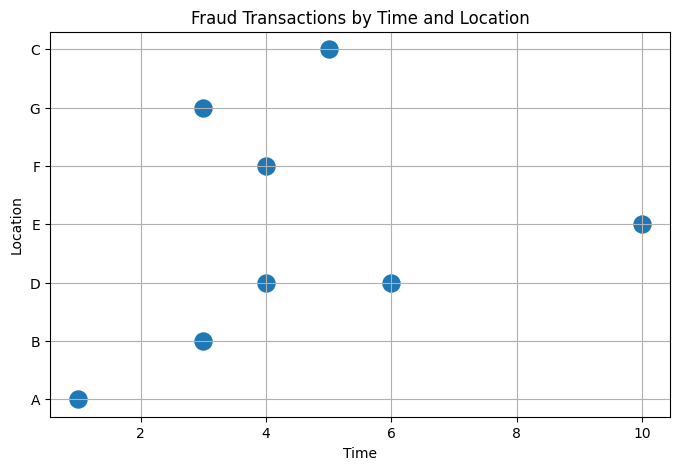

In [11]:
# Unusual Transactions (Decimal Amounts)

df["Unusual_Transaction"] = df["transaction_amount"].apply(
    lambda x: "Yes" if x % 1 != 0 else "No"
)

print("\nUnusual Transactions:")
print(df[df["Unusual_Transaction"] == "Yes"])
print("--------------------------------------------------------------------------------------")

# High Risk Accounts

high_risk_accounts = df[
    (df["Account_Activity"] == "inactive")
]

print("\nHigh Risk Accounts:")
print(high_risk_accounts)
print("--------------------------------------------------------------------------------------")
# Fraud Pattern Detection

df["Fraud_Pattern"] = df.apply(
    lambda row: "Fraud"
    if (row["transaction_amount"] % 1 != 0) or
       (row["Account_Activity"] == "inactive")
    else "Normal",
    axis=1
)

print("\nFraud Pattern Analysis:")
print(df)
print("--------------------------------------------------------------------------------------")
# Visualization
fraud_pattern = df[df["Fraud_Pattern"] == "Fraud"]

plt.figure(figsize=(8, 5))

plt.scatter(
    fraud_pattern["time"],
    fraud_pattern["location"],
    s=150
)
print("--------------------------------------------------------------------------------------")
plt.xlabel("Time")
plt.ylabel("Location")
plt.title("Fraud Transactions by Time and Location")
plt.grid(True)

plt.show()